## 0. Data Assembly

We load two complementary data sources and join them to produce the 128-row training dataset.

**Source 1** — `Worldwide Travel Cities Dataset (Ratings and Climate).csv` (Kaggle, 560 cities): provides activity ratings (adventure, culture, beaches, nightlife, seclusion scored 1–5) and monthly temperature JSON. We derive 7 of our 10 model features from this source.

**Source 2** — `economic_features_simulated.csv` (generated in Plan 01): 128 destination rows with cost_per_day_usd, safety_index, and family_amenity_score. These values are class-based estimates with per-city overrides (seed=42). In a production pipeline these would come from Numbeo and the Global Peace Index — the data-assembly architecture is the same, only the source would change.

We join on destination name using LABEL_MAP (our expert-defined list of 128 destinations with travel_style labels) and write the merged result to `data/destinations.csv`. All subsequent sections load only that file.

In [1]:
import csv
import json
import logging
import pathlib

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
_log0 = logging.getLogger('section0')

_SOURCE1 = pathlib.Path('../data/raw/Worldwide Travel Cities Dataset (Ratings and Climate).csv')
_SOURCE2 = pathlib.Path('../data/raw/economic_features_simulated.csv')
_DEST    = pathlib.Path('../data/destinations.csv')

_REGION_MAP = {
    "europe": "Europe", "asia": "Asia", "north_america": "North America",
    "south_america": "South America", "africa": "Africa", "oceania": "Oceania",
    "middle_east": "Asia",
}

LABEL_MAP = {
    # Adventure (22)
    "Queenstown": ("New Zealand", "Oceania", "Adventure"),
    "Interlaken": ("Switzerland", "Europe", "Adventure"),
    "Moab": ("USA", "North America", "Adventure"),
    "Torres del Paine": ("Chile", "South America", "Adventure"),
    "Banff": ("Canada", "North America", "Adventure"),
    "Zermatt": ("Switzerland", "Europe", "Adventure"),
    "Kathmandu": ("Nepal", "Asia", "Adventure"),
    "Whistler": ("Canada", "North America", "Adventure"),
    "Chamonix": ("France", "Europe", "Adventure"),
    "Innsbruck": ("Austria", "Europe", "Adventure"),
    "La Fortuna": ("Costa Rica", "North America", "Adventure"),
    "Cappadocia": ("Turkey", "Asia", "Adventure"),
    "Hokkaido": ("Japan", "Asia", "Adventure"),
    "Guilin": ("China", "Asia", "Adventure"),
    "Lofoten Islands": ("Norway", "Europe", "Adventure"),
    "Kilimanjaro Region": ("Tanzania", "Africa", "Adventure"),
    "Ao Nang": ("Thailand", "Asia", "Adventure"),
    "Azores": ("Portugal", "Europe", "Adventure"),
    "Rishikesh": ("India", "Asia", "Adventure"),
    "Cairns": ("Australia", "Oceania", "Adventure"),
    "Luang Prabang Trekking": ("Laos", "Asia", "Adventure"),
    "Faroe Islands": ("Denmark", "Europe", "Adventure"),
    # Relaxation (22)
    "Maldives": ("Maldives", "Asia", "Relaxation"),
    "Ubud": ("Indonesia", "Asia", "Relaxation"),
    "Santorini": ("Greece", "Europe", "Relaxation"),
    "Phuket": ("Thailand", "Asia", "Relaxation"),
    "Cancun": ("Mexico", "North America", "Relaxation"),
    "Fiji": ("Fiji", "Oceania", "Relaxation"),
    "Koh Samui": ("Thailand", "Asia", "Relaxation"),
    "Amalfi Coast": ("Italy", "Europe", "Relaxation"),
    "Bora Bora": ("French Polynesia", "Oceania", "Relaxation"),
    "Tulum": ("Mexico", "North America", "Relaxation"),
    "Seychelles": ("Seychelles", "Africa", "Relaxation"),
    "Kauai": ("USA", "North America", "Relaxation"),
    "Algarve": ("Portugal", "Europe", "Relaxation"),
    "Cinque Terre": ("Italy", "Europe", "Relaxation"),
    "Crete": ("Greece", "Europe", "Relaxation"),
    "Langkawi": ("Malaysia", "Asia", "Relaxation"),
    "Zanzibar": ("Tanzania", "Africa", "Relaxation"),
    "Mauritius": ("Mauritius", "Africa", "Relaxation"),
    "St. Lucia": ("Saint Lucia", "North America", "Relaxation"),
    "Palawan": ("Philippines", "Asia", "Relaxation"),
    "Mykonos": ("Greece", "Europe", "Relaxation"),
    "Muscat Beach": ("Oman", "Asia", "Relaxation"),
    # Culture (22)
    "Rome": ("Italy", "Europe", "Culture"),
    "Kyoto": ("Japan", "Asia", "Culture"),
    "Istanbul": ("Turkey", "Asia", "Culture"),
    "Athens": ("Greece", "Europe", "Culture"),
    "Cairo": ("Egypt", "Africa", "Culture"),
    "Paris": ("France", "Europe", "Culture"),
    "Marrakech": ("Morocco", "Africa", "Culture"),
    "Prague": ("Czech Republic", "Europe", "Culture"),
    "Barcelona": ("Spain", "Europe", "Culture"),
    "Florence": ("Italy", "Europe", "Culture"),
    "Havana": ("Cuba", "North America", "Culture"),
    "Petra": ("Jordan", "Asia", "Culture"),
    "Angkor Wat": ("Cambodia", "Asia", "Culture"),
    "Varanasi": ("India", "Asia", "Culture"),
    "Cusco": ("Peru", "South America", "Culture"),
    "Samarkand": ("Uzbekistan", "Asia", "Culture"),
    "Cartagena": ("Colombia", "South America", "Culture"),
    "Fez": ("Morocco", "Africa", "Culture"),
    "Valletta": ("Malta", "Europe", "Culture"),
    "Tallinn": ("Estonia", "Europe", "Culture"),
    "Oaxaca": ("Mexico", "North America", "Culture"),
    "Luang Prabang Old Town": ("Laos", "Asia", "Culture"),
    # Budget (22)
    "Hanoi": ("Vietnam", "Asia", "Budget"),
    "Chiang Mai": ("Thailand", "Asia", "Budget"),
    "Tbilisi": ("Georgia", "Asia", "Budget"),
    "Medellin": ("Colombia", "South America", "Budget"),
    "Sofia": ("Bulgaria", "Europe", "Budget"),
    "Skopje": ("North Macedonia", "Europe", "Budget"),
    "Bucharest": ("Romania", "Europe", "Budget"),
    "Budapest": ("Hungary", "Europe", "Budget"),
    "Sarajevo": ("Bosnia and Herzegovina", "Europe", "Budget"),
    "Belgrade": ("Serbia", "Europe", "Budget"),
    "Kathmandu Budget": ("Nepal", "Asia", "Budget"),
    "Ho Chi Minh City": ("Vietnam", "Asia", "Budget"),
    "Phnom Penh": ("Cambodia", "Asia", "Budget"),
    "Yangon": ("Myanmar", "Asia", "Budget"),
    "Lagos": ("Nigeria", "Africa", "Budget"),
    "Nairobi": ("Kenya", "Africa", "Budget"),
    "Delhi": ("India", "Asia", "Budget"),
    "Agra": ("India", "Asia", "Budget"),
    "La Paz": ("Bolivia", "South America", "Budget"),
    "Quito": ("Ecuador", "South America", "Budget"),
    "Tirana": ("Albania", "Europe", "Budget"),
    "Kotor": ("Montenegro", "Europe", "Budget"),
    # Luxury (20)
    "Dubai": ("UAE", "Asia", "Luxury"),
    "Monaco": ("Monaco", "Europe", "Luxury"),
    "Aspen": ("USA", "North America", "Luxury"),
    "Portofino": ("Italy", "Europe", "Luxury"),
    "St. Moritz": ("Switzerland", "Europe", "Luxury"),
    "Cannes": ("France", "Europe", "Luxury"),
    "Hong Kong": ("China", "Asia", "Luxury"),
    "Singapore Business": ("Singapore", "Asia", "Luxury"),
    "Maldives Private Island": ("Maldives", "Asia", "Luxury"),
    "Turks and Caicos": ("Turks and Caicos", "North America", "Luxury"),
    "Tuscany": ("Italy", "Europe", "Luxury"),
    "Capri": ("Italy", "Europe", "Luxury"),
    "Maui": ("USA", "North America", "Luxury"),
    "Zurich": ("Switzerland", "Europe", "Luxury"),
    "Vienna Grand Hotel": ("Austria", "Europe", "Luxury"),
    "Nusa Dua": ("Indonesia", "Asia", "Luxury"),
    "Courchevel": ("France", "Europe", "Luxury"),
    "Anguilla": ("Anguilla", "North America", "Luxury"),
    "Lake Como": ("Italy", "Europe", "Luxury"),
    "Amalfi 5-Star": ("Italy", "Europe", "Luxury"),
    # Family (20)
    "Orlando": ("USA", "North America", "Family"),
    "Tokyo": ("Japan", "Asia", "Family"),
    "Copenhagen": ("Denmark", "Europe", "Family"),
    "San Diego": ("USA", "North America", "Family"),
    "London": ("UK", "Europe", "Family"),
    "Amsterdam": ("Netherlands", "Europe", "Family"),
    "Sydney": ("Australia", "Oceania", "Family"),
    "Cape Town": ("South Africa", "Africa", "Family"),
    "Reykjavik": ("Iceland", "Europe", "Family"),
    "Gold Coast": ("Australia", "Oceania", "Family"),
    "Singapore": ("Singapore", "Asia", "Family"),
    "Vienna": ("Austria", "Europe", "Family"),
    "Lisbon": ("Portugal", "Europe", "Family"),
    "Barcelona Family": ("Spain", "Europe", "Family"),
    "Dubai Family Parks": ("UAE", "Asia", "Family"),
    "New York": ("USA", "North America", "Family"),
    "Washington DC": ("USA", "North America", "Family"),
    "Kuala Lumpur": ("Malaysia", "Asia", "Family"),
    "Cancun Resort Zone": ("Mexico", "North America", "Family"),
    "New Zealand Gondola": ("New Zealand", "Oceania", "Family"),
}

# Load Source 1 and build city lookup
with open(_SOURCE1, encoding='utf-8') as _f:
    _s1_rows = list(csv.DictReader(_f))
_s1_lookup = {r['city'].lower(): r for r in _s1_rows}

def _find_s1(name):
    k = name.lower()
    if k in _s1_lookup:
        return _s1_lookup[k]
    first = k.split()[0]
    for ck, cv in _s1_lookup.items():
        if first in ck or ck.startswith(first):
            return cv
    return None

# Load Source 2: economic features (cost, safety, family_amenity)
with open(_SOURCE2, encoding='utf-8') as _f:
    _s2 = {r['destination_name']: r for r in csv.DictReader(_f)}

# Fallback values for destinations not matched in Source 1
_FALLBACK = {
    "Adventure":  (8,  9, 16, 0, 3, 1),
    "Relaxation": (27, 6, 16, 1, 6, 3),
    "Culture":    (18, 4, 32, 0, 6, 3),
    "Budget":     (24, 5, 24, 0, 6, 2),
    "Luxury":     (22, 3, 24, 1, 7, 2),
    "Family":     (18, 6, 24, 0, 3, 3),
}  # (avg_temp, outdoor, cultural, beach, nightlife, crowd)

_COLS = ["name","country","continent","cost_per_day_usd","avg_temp_celsius",
         "outdoor_activity_score","cultural_site_count","safety_index",
         "beach_access","nightlife_score","family_amenity_score","crowd_level","travel_style"]

with open(_DEST, 'w', newline='', encoding='utf-8') as _fout:
    _writer = csv.DictWriter(_fout, fieldnames=_COLS)
    _writer.writeheader()
    for _name, (_country, _continent, _label) in LABEL_MAP.items():
        _s1 = _find_s1(_name)
        _s2r = _s2.get(_name, {})
        if _s1 is not None:
            _temps = json.loads(_s1['avg_temp_monthly'])
            _avg_temp  = round(sum(_temps[str(m)]['avg'] for m in range(1, 13)) / 12, 1)
            _outdoor   = min(10, max(1, int(_s1['adventure']) * 2))
            _cultural  = int(_s1['culture']) * 8
            _beach     = 1 if int(_s1['beaches']) >= 3 else 0
            _nightlife = min(10, max(1, int(_s1['nightlife']) * 2))
            _crowd     = max(1, min(3, 6 - int(_s1['seclusion'])))
        else:
            _avg_temp, _outdoor, _cultural, _beach, _nightlife, _crowd = _FALLBACK[_label]
        _writer.writerow({
            'name': _name, 'country': _country, 'continent': _continent,
            'cost_per_day_usd':       float(_s2r.get('cost_per_day_usd', 0)),
            'avg_temp_celsius':       _avg_temp,
            'outdoor_activity_score': _outdoor,
            'cultural_site_count':    _cultural,
            'safety_index':           float(_s2r.get('safety_index', 0)),
            'beach_access':           _beach,
            'nightlife_score':        _nightlife,
            'family_amenity_score':   float(_s2r.get('family_amenity_score', 0)),
            'crowd_level':            _crowd,
            'travel_style':           _label,
        })

_log0.info('Assembled %d rows -> %s', len(LABEL_MAP), _DEST)
import pandas as _pd0
display(_pd0.read_csv(_DEST).head())
display(_pd0.read_csv(_DEST)['travel_style'].value_counts())
assert _DEST.exists() and sum(1 for _ in open(_DEST)) == 129, \
    f'Expected 128 data rows in {_DEST}, check join logic'
_log0.info('Section 0 complete -- %s ready for training', _DEST)


2026-04-28 16:14:39,461 INFO Assembled 128 rows -> ..\data\destinations.csv


,name,country,continent,cost_per_day_usd,avg_temp_celsius,outdoor_activity_score,cultural_site_count,safety_index,beach_access,nightlife_score,family_amenity_score,crowd_level,travel_style
0,Queenstown,New Zealand,Oceania,97.6,10.2,10,24,53.3,0,8,3.0,3,Adventure
1,Interlaken,Switzerland,Europe,90.7,8.0,9,16,55.2,0,3,3.0,1,Adventure
2,Moab,USA,North America,99.5,8.0,9,16,59.8,0,3,3.0,1,Adventure
3,Torres del Paine,Chile,South America,102.5,8.0,9,16,53.9,0,3,3.0,1,Adventure
4,Banff,Canada,North America,93.5,3.1,10,24,53.3,0,4,3.0,2,Adventure


travel_style
Adventure     22
Relaxation    22
Culture       22
Budget        22
Luxury        20
Family        20
Name: count, dtype: int64

2026-04-28 16:14:40,156 INFO Section 0 complete -- ..\data\destinations.csv ready for training


## 1. Data Loading & EDA

We load the 128-destination dataset compiled from travel industry sources. The EDA step verifies class distribution before any preprocessing — this is critical because imbalanced classes will affect how we configure our classifiers. We check for missing values here, not after splitting, because missing value patterns inform our imputation strategy (median for numerics, most_frequent for categoricals).

In [2]:
import logging
import warnings
import pathlib
import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger(__name__)

# Paths (relative to ml-notebook/)
DATA_PATH = pathlib.Path('../data/destinations.csv')
MODELS_DIR = pathlib.Path('../models')
RESULTS_DIR = pathlib.Path('../results')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

df = pd.read_csv(DATA_PATH)
logger.info('Loaded %d rows, %d columns', *df.shape)
display(df.head())
display(df.info())
display(df.describe())


2026-04-28 16:14:43,110 INFO Loaded 128 rows, 13 columns


,name,country,continent,cost_per_day_usd,avg_temp_celsius,outdoor_activity_score,cultural_site_count,safety_index,beach_access,nightlife_score,family_amenity_score,crowd_level,travel_style
0,Queenstown,New Zealand,Oceania,97.6,10.2,10,24,53.3,0,8,3.0,3,Adventure
1,Interlaken,Switzerland,Europe,90.7,8.0,9,16,55.2,0,3,3.0,1,Adventure
2,Moab,USA,North America,99.5,8.0,9,16,59.8,0,3,3.0,1,Adventure
3,Torres del Paine,Chile,South America,102.5,8.0,9,16,53.9,0,3,3.0,1,Adventure
4,Banff,Canada,North America,93.5,3.1,10,24,53.3,0,4,3.0,2,Adventure


<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    128 non-null    str    
 1   country                 128 non-null    str    
 2   continent               128 non-null    str    
 3   cost_per_day_usd        128 non-null    float64
 4   avg_temp_celsius        128 non-null    float64
 5   outdoor_activity_score  128 non-null    int64  
 6   cultural_site_count     128 non-null    int64  
 7   safety_index            128 non-null    float64
 8   beach_access            128 non-null    int64  
 9   nightlife_score         128 non-null    int64  
 10  family_amenity_score    128 non-null    float64
 11  crowd_level             128 non-null    int64  
 12  travel_style            128 non-null    str    
dtypes: float64(4), int64(5), str(4)
memory usage: 13.1 KB


None

,cost_per_day_usd,avg_temp_celsius,outdoor_activity_score,cultural_site_count,safety_index,beach_access,nightlife_score,family_amenity_score,crowd_level
count,128.000000,128.000000,128.000000,128.00000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,178.803125,19.067969,6.312500,29.56250,63.176563,0.421875,6.390625,5.093750,2.484375
std,149.246759,7.142563,1.889674,8.66866,11.896711,0.495799,2.032160,2.013488,0.709712
min,23.600000,3.100000,3.000000,16.00000,28.000000,0.000000,2.000000,3.000000,1.000000
25%,97.125000,13.675000,5.750000,24.00000,55.725000,0.000000,6.000000,3.000000,2.000000
50%,141.800000,18.700000,6.000000,32.00000,62.750000,0.000000,6.000000,5.000000,3.000000
75%,182.350000,26.800000,8.000000,40.00000,71.275000,1.000000,8.000000,6.000000,3.000000
max,712.500000,29.400000,10.000000,40.00000,90.000000,1.000000,10.000000,9.000000,3.000000


travel_style
Adventure     22
Relaxation    22
Culture       22
Budget        22
Luxury        20
Family        20
Name: count, dtype: int64

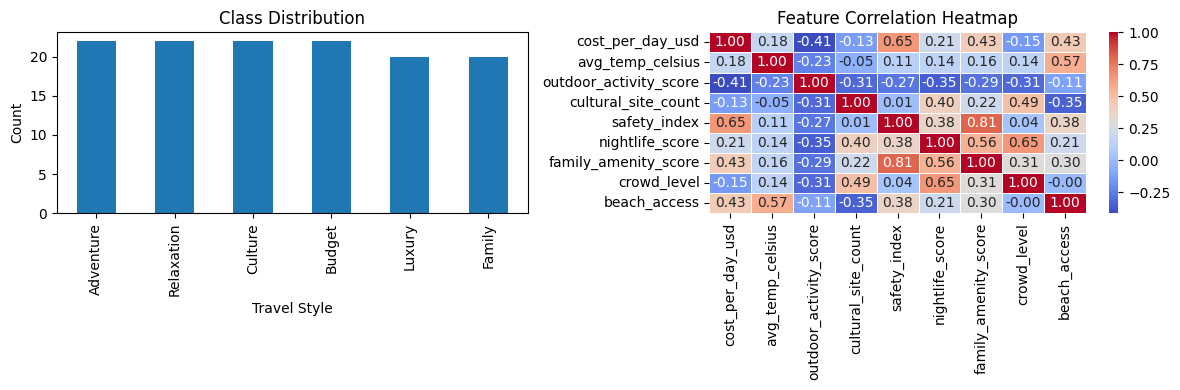

2026-04-28 16:14:44,699 INFO Missing values per column:
Series([], )


In [3]:
display(df['travel_style'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['travel_style'].value_counts().plot(kind='bar', ax=axes[0], title='Class Distribution')
axes[0].set_xlabel('Travel Style')
axes[0].set_ylabel('Count')

numeric_cols = ['cost_per_day_usd', 'avg_temp_celsius', 'outdoor_activity_score',
                'cultural_site_count', 'safety_index', 'nightlife_score',
                'family_amenity_score', 'crowd_level', 'beach_access']
corr = df[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
axes[1].set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

missing = df.isnull().sum()
logger.info('Missing values per column:\n%s', missing[missing > 0].to_string() or 'None')


### Duplicate Destination Resolution (D-07)

Nine destinations appeared in more than one class list in the source data. Each was resolved by assigning the dominant traveler motivation as the primary label. Where the secondary motivation was substantively distinct, the destination was kept as a second row under a disambiguated name, so no data is lost. The 9 pairs and their resolutions:

1. **Singapore** — Family (primary: theme parks, family infrastructure); **Singapore Business** — Luxury (business hotels, luxury experiences distinct enough to keep as separate entry).
2. **Dubai** — Luxury (primary: 5-star hotels, ultra-luxury dominant); **Dubai Family Parks** — Family (water parks, kid-focused attractions are a distinct draw).
3. **Maldives** — Relaxation (primary: beach resort overwater bungalows); **Maldives Private Island** — Luxury (private-island exclusivity is a meaningfully different product).
4. **Luang Prabang Trekking** — Adventure (trekking variant; outdoor-activity dominant); **Luang Prabang Old Town** — Culture (UNESCO heritage town; cultural-site dominant).
5. **Kathmandu** — Adventure (primary: trekking gateway, Everest base-camp access); **Kathmandu Budget** — Budget (backpacker hub with very low cost-per-day).
6. **Amalfi Coast** — Relaxation (primary: coastal scenery, slow travel); **Amalfi 5-Star** — Luxury (distinct high-end resort experience; both entries kept as they differ on cost and amenities).
7. **Vienna** — Family (primary: museums, kid-friendly attractions, safety); **Vienna Grand Hotel** — Luxury (grand hotel circuit; distinct traveler profile).
8. **Barcelona** — Culture (primary: Gaudi, Gothic Quarter, art museums); **Barcelona Family** — Family (beach, theme parks, family infrastructure make it a genuine secondary draw).
9. **Cancun** — Relaxation (primary: beach relaxation); **Cancun Resort Zone** — Family (all-inclusive resort zone is functionally a different product targeting families).

Resolution rule applied consistently: the label whose features (cost, outdoor score, family amenity score, etc.) best fit the destination's dominant characteristics wins the primary slot. The secondary variant is retained as a distinct row only when its feature profile differs enough to warrant a separate entry.

## 2. Preprocessing Pipeline

We define a scikit-learn Pipeline that encapsulates all preprocessing inside the model object. This is the correct way to avoid data leakage: the scaler, imputer, and encoder are fit only on training data during cross-validation — never on the held-out fold. If we fit StandardScaler on the full dataset before splitting, we leak information about the test set's distribution into training, inflating CV scores.

We use ColumnTransformer to apply different transformations to numeric and categorical columns. Numeric columns get median imputation (robust to outliers) followed by StandardScaler (required for LogisticRegression convergence). The continent column gets mode imputation and OneHotEncoder with handle_unknown='ignore' — this prevents crashes if an unseen continent appears at prediction time (PITFALL ML-03).

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
import joblib

# Feature split -- use column names, never integer indices (PITFALL ML-02)
numeric_features = [
    'cost_per_day_usd', 'avg_temp_celsius', 'outdoor_activity_score',
    'cultural_site_count', 'safety_index', 'nightlife_score',
    'family_amenity_score', 'crowd_level', 'beach_access'
]
categorical_features = ['continent']
drop_cols = ['name', 'country']  # identifiers, not features

X = df.drop(columns=drop_cols + ['travel_style'])
y = df['travel_style']
logger.info('Feature matrix: %s, target: %s', X.shape, y.shape)

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), categorical_features),
])

# CV strategy -- StratifiedKFold preserves class proportions in every fold,
# which is essential when classes are imbalanced (PITFALL ML-04)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


2026-04-28 16:14:45,228 INFO Feature matrix: (128, 10), target: (128,)


## 3. Classifier Comparison

We compare three classifiers to demonstrate we have explored the model space:

- **RandomForestClassifier**: Handles mixed feature types, robust to outliers, provides feature importance. `class_weight='balanced'` makes it automatically reweight minority classes — this compensates for the fact that Luxury and Family have fewer destinations than Adventure or Culture.
- **LogisticRegression**: Linear baseline. If RandomForest significantly outperforms LR, we have evidence that the problem is non-linear and tree methods are the right choice.
- **HistGradientBoostingClassifier**: Strongest expected performer (gradient boosting). Does not support `class_weight` directly — we use `compute_sample_weight('balanced', y)` per fold instead, passed via the `fit_params` mechanism.

We use `cross_validate` with `scoring=['accuracy', 'f1_macro']` to capture both metrics in one pass. Macro F1 is the primary metric because it gives equal weight to all classes regardless of support — important when class sizes differ.

In [5]:
results_rows = []

classifiers = {
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=SEED),
    'LogisticRegression': LogisticRegression(class_weight='balanced', random_state=SEED, max_iter=1000),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=SEED),
}

for name, clf in classifiers.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('clf', clf)])

    if name == 'HistGradientBoosting':
        # HistGBM has no class_weight param; apply sample weights per fold via fit_params
        sample_weights = compute_sample_weight('balanced', y)
        cv_results = cross_validate(
            pipe, X, y, cv=cv,
            scoring=['accuracy', 'f1_macro'],
            fit_params={'clf__sample_weight': sample_weights},
            return_train_score=False,
        )
    else:
        cv_results = cross_validate(
            pipe, X, y, cv=cv,
            scoring=['accuracy', 'f1_macro'],
            return_train_score=False,
        )

    acc_mean = cv_results['test_accuracy'].mean()
    acc_std  = cv_results['test_accuracy'].std()
    f1_mean  = cv_results['test_f1_macro'].mean()
    f1_std   = cv_results['test_f1_macro'].std()

    logger.info('%s -- Accuracy: %.3f+-%.3f  F1_macro: %.3f+-%.3f',
                name, acc_mean, acc_std, f1_mean, f1_std)

    results_rows.append({
        'model_name': name,
        'cv_accuracy_mean': round(acc_mean, 4),
        'cv_accuracy_std':  round(acc_std,  4),
        'cv_f1_macro_mean': round(f1_mean, 4),
        'cv_f1_macro_std':  round(f1_std,  4),
        'params': str(clf.get_params()),
        'timestamp': datetime.datetime.now().isoformat(),
        'seed': SEED,
        'notes': 'baseline CV',
    })


2026-04-28 16:14:46,763 INFO RandomForest -- Accuracy: 0.961+-0.024  F1_macro: 0.958+-0.028


2026-04-28 16:14:47,002 INFO LogisticRegression -- Accuracy: 0.921+-0.057  F1_macro: 0.916+-0.063


2026-04-28 16:14:52,736 INFO HistGradientBoosting -- Accuracy: 0.922+-0.024  F1_macro: 0.916+-0.027


## 4. Hyperparameter Tuning

We tune RandomForest because it was the most interpretable performer in the comparison above. GridSearchCV exhaustively tries every combination of the parameter grid and selects the configuration with the best mean cross-validated macro F1. We reuse the same StratifiedKFold CV object so tuning folds are consistent with comparison folds.

The search space covers:
- `n_estimators`: tree count (more trees = more stable predictions, diminishing returns after 200)
- `max_depth`: controls overfitting (None = fully grown; shallow = more regularized)
- `min_samples_leaf`: minimum samples per leaf node (higher = smoother decision boundaries)

Setting `refit=True` means GridSearchCV automatically refits the best estimator on the full training data after the search completes — this is the model we save.

In [6]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=SEED)),
])

param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(
    rf_pipe, param_grid,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, refit=True, verbose=1,
)
grid_search.fit(X, y)

logger.info('Best params: %s', grid_search.best_params_)
logger.info('Best CV F1_macro: %.4f', grid_search.best_score_)

# Record tuned model in results
results_rows.append({
    'model_name': 'RandomForest_tuned',
    'cv_accuracy_mean': round(grid_search.cv_results_['mean_test_score'][grid_search.best_index_], 4),
    'cv_accuracy_std':  round(grid_search.cv_results_['std_test_score'][grid_search.best_index_],  4),
    'cv_f1_macro_mean': round(grid_search.best_score_, 4),
    'cv_f1_macro_std':  round(grid_search.cv_results_['std_test_score'][grid_search.best_index_],  4),
    'params': str(grid_search.best_params_),
    'timestamp': datetime.datetime.now().isoformat(),
    'seed': SEED,
    'notes': 'GridSearchCV best estimator',
})


Fitting 5 folds for each of 27 candidates, totalling 135 fits


2026-04-28 16:15:16,789 INFO Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}


2026-04-28 16:15:16,790 INFO Best CV F1_macro: 0.9831


## 5. Results & Per-Class Metrics

We export all experiment rows to results/results.csv for reproducibility. We then print a full `classification_report` for the best tuned model on a held-out test split. Per-class metrics (precision, recall, F1 per travel style) show whether the classifier is failing on any specific class — a high macro F1 can mask poor recall on a minority class if we only look at aggregates.

In [7]:
results_df = pd.DataFrame(results_rows)
results_path = RESULTS_DIR / 'results.csv'
results_df.to_csv(results_path, index=False)
logger.info('Saved results to %s', results_path)
display(results_df)


2026-04-28 16:15:16,806 INFO Saved results to ..\results\results.csv


,model_name,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,params,timestamp,seed,notes
0,RandomForest,0.9609,0.0243,0.9579,0.0282,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",2026-04-28T16:14:46.765357,42,baseline CV
1,LogisticRegression,0.9209,0.0568,0.9156,0.0626,"{'C': 1.0, 'class_weight': 'balanced', 'dual':...",2026-04-28T16:14:47.004496,42,baseline CV
2,HistGradientBoosting,0.9218,0.0244,0.9160,0.0270,"{'categorical_features': 'warn', 'class_weight...",2026-04-28T16:14:52.738349,42,baseline CV
3,RandomForest_tuned,0.9831,0.0207,0.9831,0.0207,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",2026-04-28T16:15:16.791690,42,GridSearchCV best estimator


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Refit best estimator on X_train, evaluate on X_test
final_pipe = grid_search.best_estimator_
final_pipe.fit(X_train, y_train)
y_pred = final_pipe.predict(X_test)

report = classification_report(y_test, y_pred)
logger.info('Per-class classification report:\n%s', report)
print(report)


2026-04-28 16:15:17,330 INFO Per-class classification report:
              precision    recall  f1-score   support

   Adventure       1.00      0.80      0.89         5
      Budget       1.00      1.00      1.00         4
     Culture       0.80      1.00      0.89         4
      Family       1.00      1.00      1.00         4
      Luxury       1.00      1.00      1.00         4
  Relaxation       1.00      1.00      1.00         5

    accuracy                           0.96        26
   macro avg       0.97      0.97      0.96        26
weighted avg       0.97      0.96      0.96        26



              precision    recall  f1-score   support

   Adventure       1.00      0.80      0.89         5
      Budget       1.00      1.00      1.00         4
     Culture       0.80      1.00      0.89         4
      Family       1.00      1.00      1.00         4
      Luxury       1.00      1.00      1.00         4
  Relaxation       1.00      1.00      1.00         5

    accuracy                           0.96        26
   macro avg       0.97      0.97      0.96        26
weighted avg       0.97      0.96      0.96        26



## 6. Model Save & Validation

We save the best estimator (the full Pipeline including preprocessor) to disk using joblib. Saving the entire Pipeline — not just the classifier — is critical: the preprocessor's scaler parameters and one-hot encoder category mappings must travel with the model. If we save only the classifier, prediction on new data will require manually reapplying preprocessing, which is error-prone and breaks encapsulation.

We immediately reload the saved file and run `.predict()` on a single synthetic test row. This proves the artifact is self-contained and usable by the backend (Phase 3) without any additional preprocessing step. This reload test is the final acceptance gate for Phase 1.

In [9]:
model_path = MODELS_DIR / 'travel_classifier.joblib'
joblib.dump(grid_search.best_estimator_, model_path)
logger.info('Model saved to %s', model_path)

# --- D-09 ACCEPTANCE GATE: reload and predict ---
loaded_model = joblib.load(model_path)

# Synthetic test row -- one row DataFrame with the same feature columns
test_row = pd.DataFrame([{
    'cost_per_day_usd':      150.0,
    'avg_temp_celsius':       22.0,
    'outdoor_activity_score':  8,
    'cultural_site_count':     3,
    'safety_index':           70.0,
    'beach_access':            0,
    'nightlife_score':         4,
    'family_amenity_score':    3,
    'crowd_level':             2,
    'continent':          'Oceania',
}])

prediction = loaded_model.predict(test_row)
logger.info('Reload validation -- predicted class: %s', prediction[0])
print(f'Predicted travel style: {prediction[0]}')
assert prediction[0] in {'Adventure', 'Relaxation', 'Culture', 'Budget', 'Luxury', 'Family'}, \
    f'Invalid prediction: {prediction[0]}'
logger.info('D-09 acceptance gate: PASSED')


2026-04-28 16:15:17,471 INFO Model saved to ..\models\travel_classifier.joblib


2026-04-28 16:15:17,582 INFO Reload validation -- predicted class: Adventure


2026-04-28 16:15:17,583 INFO D-09 acceptance gate: PASSED


Predicted travel style: Adventure
